In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import time
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
class Modality_Inspector(nn.Module):
    
    def __init__(self, num_classes=6):
        
        super(Modality_Inspector, self).__init__()
        
        # 输入形状: (batch_size, 256, 64, 64)
        self.feature_extractor = nn.Sequential(
            # 第一卷积层
            nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4),  # 输出: (128, 16, 16)
            
            # 第二卷积层
            nn.Conv2d(in_channels=128, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4),  # 输出: (32, 4, 4)
            
            # # 第三卷积层
            # nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, padding=1),
            # nn.BatchNorm2d(32),
            # nn.ReLU(),
            # nn.MaxPool2d(kernel_size=4),  # 输出: (32, 8, 8)
        )
        
        # 计算全连接层输入特征数
        self.flatten = nn.Flatten()
        
        # 分类头
        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        features = self.feature_extractor(x)  # 提取特征
        flattened = self.flatten(features)    # 展平
        output = self.classifier(flattened)   # 分类
        return output

In [7]:
# 医疗图像数据集类
class Medcial_Dataset(Dataset):
    
    def __init__(self, files, labels, folder=""):
        self.folder = folder
        self.files = files
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        self.data = torch.load(os.path.join(self.folder, self.files[idx]))
        return self.data, self.labels[idx]

In [8]:
data_dic = {
    "CVC_ClinicDB" : 0, # Colonoscopy   - 612 img / 612 mask
    "Darwin": 1,        # X-ray         - 6106 img / 6106 mask
    "DRIVE": 2,         # Fundus        - 40 img / 40 mask
    "DSB_2018": 3,      # Microscopy    - 670 img / 670 mask
    "ISIC_2018": 4,     # Dermoscopy    - 3694 img / 3694 mask
    "Montgomery": 1,    # X-ray         - 138 img / 138 mask
    "PCXA": 1,          # X-ray         - 55 img / 55 mask
    "Shenzhen" : 1,     # X-ray         - 566 img / 566 mask
    "UDIAT" : 5         # Ultrasound    - 163 img / 163 mask
}

idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [19]:
datafolder = "../SAM_mobile_features/image_feature"

files = os.listdir(datafolder)
labels = []
for f in files:
    labels.append(data_dic[f.split("_set_file_")[0]])

X_train, X_val, y_train, y_val = train_test_split(
    files, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [20]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_val))

Counter({1: 5362, 4: 2955, 3: 536, 0: 490, 5: 130, 2: 32})
Counter({1: 1341, 4: 739, 3: 134, 0: 122, 5: 33, 2: 8})


In [21]:
train_dataset = Medcial_Dataset(X_train, y_train, datafolder)
val_dataset = Medcial_Dataset(X_val, y_val, datafolder)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [23]:
def train_epoch(model, dataloader, criterion, optimizer, device, epoch, num_epochs):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    # 创建进度条
    pbar = tqdm(dataloader, 
                desc=f'Epoch [{epoch+1}/{num_epochs}]',
                ncols=100,
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')
    
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        # 计算准确率
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        
        # 更新统计数据
        total_loss += loss.item()
        batch_loss = loss.item()
        batch_acc = 100. * (predicted == target).sum().item() / target.size(0)
        
        # 实时更新进度条信息
        pbar.set_postfix({
            'Loss': f'{batch_loss:.4f}',
            'Acc': f'{batch_acc:.2f}%',
            'Avg Loss': f'{total_loss/(batch_idx+1):.4f}',
            'Avg Acc': f'{100.*correct/total:.2f}%',
            'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
        })
    
    epoch_loss = total_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [24]:
def validate(model, dataloader, criterion, device, class_names=list(idx_name.values()), show_matrix=True, normalize=True):
    """
    验证/测试函数，包含混淆矩阵
    
    参数:
        model: 模型
        dataloader: 数据加载器
        criterion: 损失函数
        device: 设备
        class_names: 类别名称列表
        show_matrix: 是否显示混淆矩阵
        normalize: 是否归一化混淆矩阵
    
    返回:
        val_loss: 验证损失
        val_acc: 验证准确率
        cm: 混淆矩阵
        report: 分类报告
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    # 用于存储所有预测和真实标签
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, 
                    desc='Validating',
                    ncols=100,
                    bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')
        
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            
            # 计算损失
            loss = criterion(outputs, target)
            total_loss += loss.item()
            
            # 获取预测结果
            _, predicted = torch.max(outputs.data, 1)
            
            # 保存预测和真实标签
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
            # 计算准确率
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            # 更新进度条
            batch_acc = 100. * (predicted == target).sum().item() / target.size(0)
            pbar.set_postfix({
                'Val Loss': f'{loss.item():.4f}',
                'Val Acc': f'{batch_acc:.2f}%',
                'Total Acc': f'{100.*correct/total:.2f}%'
            })
    
    # 计算总指标
    val_loss = total_loss / len(dataloader)
    val_acc = 100. * correct / total
    
    # 转换为numpy数组
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    
    # 计算混淆矩阵
    num_classes = len(np.unique(all_targets))
    cm = confusion_matrix(all_targets, all_predictions, labels=range(num_classes))
    
    # 生成分类报告
    report = classification_report(all_targets, all_predictions, 
                                  target_names=class_names, output_dict=True)
    
    # 打印结果
    print(f"\n{'='*50}")
    print(f"验证结果:")
    print(f"  损失: {val_loss:.4f}")
    print(f"  准确率: {val_acc:.2f}%")
    print(f"  总样本数: {total}")
    print(f"  正确数: {correct}")
    print(f"{'='*50}")
    
    # 显示混淆矩阵
    if show_matrix:
        plot_confusion_matrix(cm, class_names=class_names, normalize=normalize)
    
    # 打印分类报告
    print_classification_report(report)
    
    return val_loss, val_acc

def plot_confusion_matrix(cm, class_names=None, normalize=True, figsize=(10, 8)):
    """
    绘制混淆矩阵
    
    参数:
        cm: 混淆矩阵
        class_names: 类别名称
        normalize: 是否归一化
        figsize: 图形大小
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'
    
    if class_names is None:
        class_names = [f'Class {i}' for i in range(cm.shape[0])]
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 绘制热力图
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    
    # 设置标签
    plt.title('Confusion Matrix', fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    # 调整刻度
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 打印数值
    print(f"\n{'='*50}")
    print("混淆矩阵:")
    if normalize:
        print("(归一化值，显示每个真实类别的预测比例)")
    else:
        print("(原始计数值)")
    print(f"{'='*50}")
    
    # 创建DataFrame便于查看
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    print("\n混淆矩阵 DataFrame:")
    print(cm_df)
    print()

def print_classification_report(report):
    """
    打印分类报告
    
    参数:
        report: sklearn的classification_report输出
    """
    print(f"\n{'='*50}")
    print("分类报告:")
    print(f"{'='*50}")
    
    if isinstance(report, str):
        # 如果是字符串格式，直接打印
        print(report)
    else:
        # 如果是字典格式，美化打印
        # 打印每个类别的指标
        for class_name, metrics in report.items():
            if class_name in ['accuracy', 'macro avg', 'weighted avg']:
                continue
            
            print(f"\n类别: {class_name}")
            print(f"  Precision: {metrics['precision']:.4f}")
            print(f"  Recall:    {metrics['recall']:.4f}")
            print(f"  F1-Score:  {metrics['f1-score']:.4f}")
            print(f"  Support:   {metrics['support']}")
        
        # 打印汇总指标
        print(f"\n{'='*30}")
        print("汇总指标:")
        if 'accuracy' in report:
            print(f"准确率: {report['accuracy']:.4f}")
        if 'macro avg' in report:
            print(f"宏平均: Precision={report['macro avg']['precision']:.4f}, "
                  f"Recall={report['macro avg']['recall']:.4f}, "
                  f"F1={report['macro avg']['f1-score']:.4f}")
        if 'weighted avg' in report:
            print(f"加权平均: Precision={report['weighted avg']['precision']:.4f}, "
                  f"Recall={report['weighted avg']['recall']:.4f}, "
                  f"F1={report['weighted avg']['f1-score']:.4f}")

In [25]:
# def validate(model, dataloader, criterion, device):
#     """验证/测试函数"""
#     model.eval()
#     total_loss = 0
#     correct = 0
#     total = 0
    
#     with torch.no_grad():
#         pbar = tqdm(dataloader, 
#                     desc='Validating',
#                     ncols=100,
#                     bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')
        
#         for data, target in pbar:
#             data, target = data.to(device), target.to(device)
#             outputs = model(data)
            
#             # 计算损失
#             loss = criterion(outputs, target)
#             total_loss += loss.item()
            
#             # 计算准确率
#             _, predicted = torch.max(outputs.data, 1)
#             total += target.size(0)
#             correct += (predicted == target).sum().item()
            
#             # 更新进度条
#             batch_acc = 100. * (predicted == target).sum().item() / target.size(0)
#             pbar.set_postfix({
#                 'Val Loss': f'{loss.item():.4f}',
#                 'Val Acc': f'{batch_acc:.2f}%',
#                 'Total Acc': f'{100.*correct/total:.2f}%'
#             })
    
#     val_loss = total_loss / len(dataloader)
#     val_acc = 100. * correct / total
    
#     return val_loss, val_acc

In [26]:
def save_checkpoint(model, optimizer, epoch, metrics, save_dir, is_best=False):
    """保存检查点"""
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': metrics.get('train_loss', 0),
        'train_acc': metrics.get('train_acc', 0),
        'val_loss': metrics.get('val_loss', 0),
        'val_acc': metrics.get('val_acc', 0)
    }
    
    # 保存常规检查点
    checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch+1:03d}.pth')
    torch.save(checkpoint, checkpoint_path)
    
    # 如果是最佳模型，额外保存
    if is_best:
        best_path = os.path.join(save_dir, 'best_mobile_modality_inspector_model.pth')
        torch.save(checkpoint, best_path)
        print(f"✅ 保存最佳模型到: {best_path}")
    
    print(f"💾 保存检查点到: {checkpoint_path}")
    return checkpoint_path


def save_training_history(history, save_dir):
    """保存训练历史到CSV文件"""
    df = pd.DataFrame(history)
    csv_path = os.path.join(save_dir, 'training_history.csv')
    df.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"📊 训练历史已保存到: {csv_path}")
    
    return csv_path


def plot_training_history(history, save_dir):
    """绘制训练曲线"""
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        epochs = range(1, len(history['train_loss']) + 1)
        
        # 损失曲线
        axes[0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
        axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
        axes[0].set_xlabel('Epoch', fontsize=12)
        axes[0].set_ylabel('Loss', fontsize=12)
        axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 准确率曲线
        axes[1].plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
        axes[1].plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Accuracy (%)', fontsize=12)
        axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # 保存图片
        plot_path = os.path.join(save_dir, 'training_curves.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"📈 训练曲线已保存到: {plot_path}")
        
    except ImportError:
        print("⚠️  Matplotlib或Seaborn未安装，跳过绘图功能")
        print("   请运行: pip install matplotlib seaborn")

可用 GPU: [0, 1]
main GPU is device 0
📁 实验保存目录: MI_experiments/exp_20260530_130415
📊 模型参数统计:
   总参数量: 365,478
   可训练参数量: 365,478
--------------------------------------------------------------------------------
📦 数据集信息:
   训练集大小: 9505
   验证集大小: 2377
   批大小: 32
--------------------------------------------------------------------------------
🚀 开始训练...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x71d885f3b920>=0.1643, Ac
Traceback (most recent call last):
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x71d885f3b920>=0.1068, Ac
Traceback (most recent call last):
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13


验证结果:
  损失: 0.0100
  准确率: 99.58%
  总样本数: 2377
  正确数: 2367


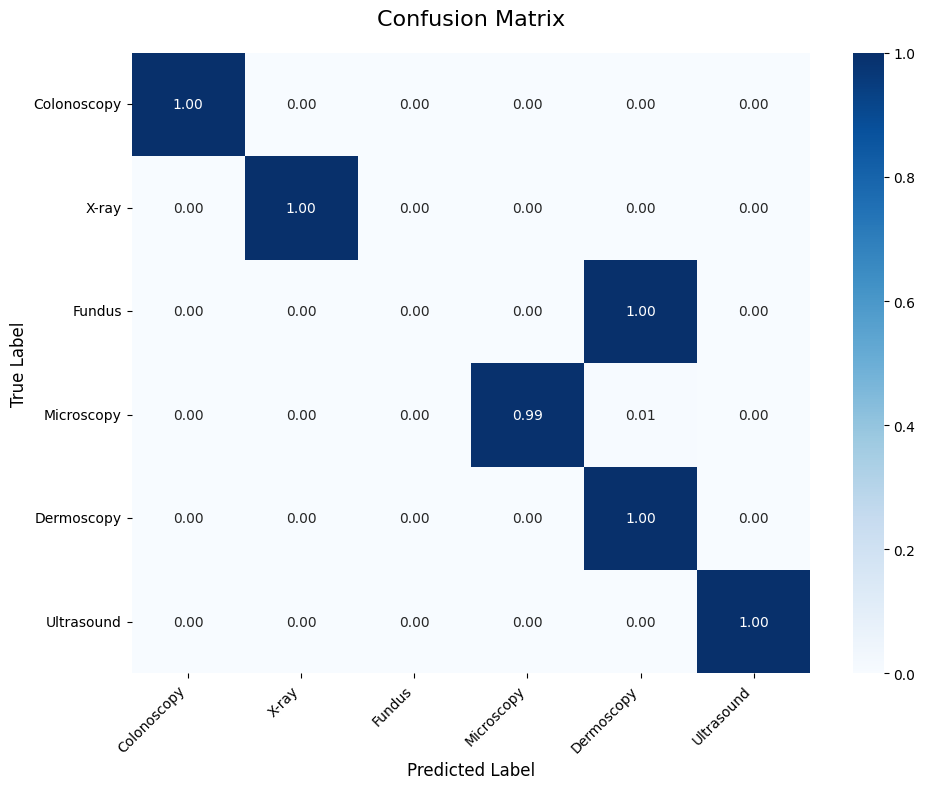


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     0.0    0.000000    1.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.001353    0.998647         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Support:   8.0

类别: Microscopy
  Precision: 0.9925
  Recall:    0.9925
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9880
  Recall

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x71d885f3b920>0.0482, Acc
Traceback (most recent call last):
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x71d885f3b920>0.0139, Acc
Traceback (most recent call last):
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/sxcks2/.conda/envs/ESP/lib/python3.13


验证结果:
  损失: 0.0037
  准确率: 99.87%
  总样本数: 2377
  正确数: 2374


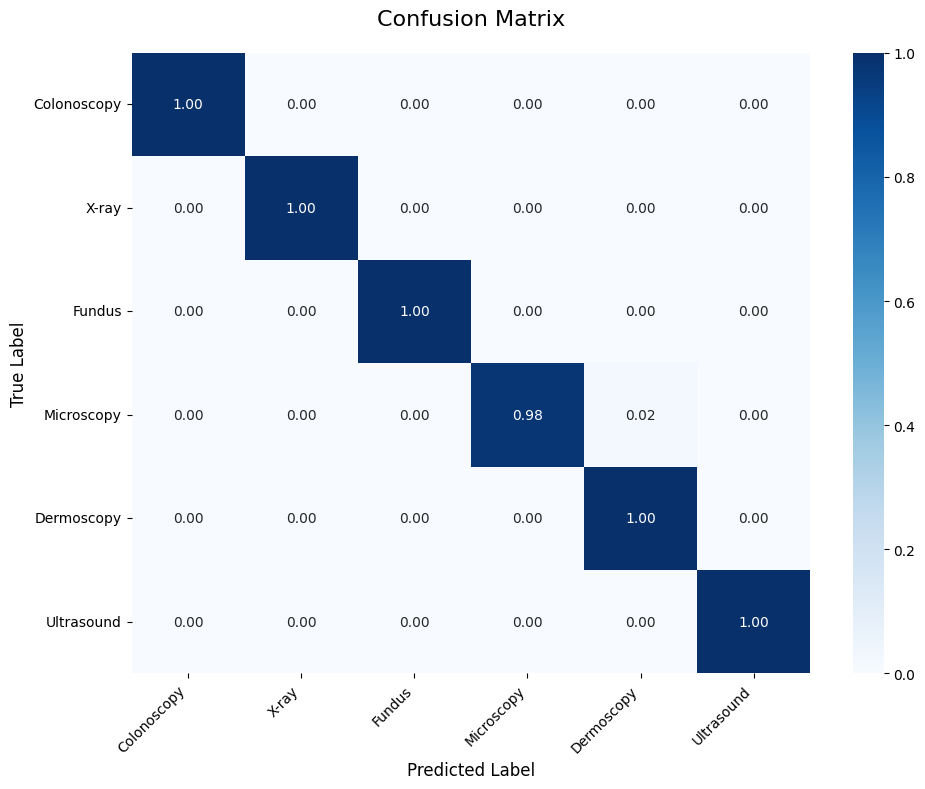


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.977612    0.022388         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9776
  F1-Score:  0.9887
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9960
  Recall

Epoch [3/100]: 100%|██████████████████████████████| 298/298 [00:28<00:00, 10.45it/s, Loss=0.0003, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.09it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0035
  准确率: 99.87%
  总样本数: 2377
  正确数: 2374


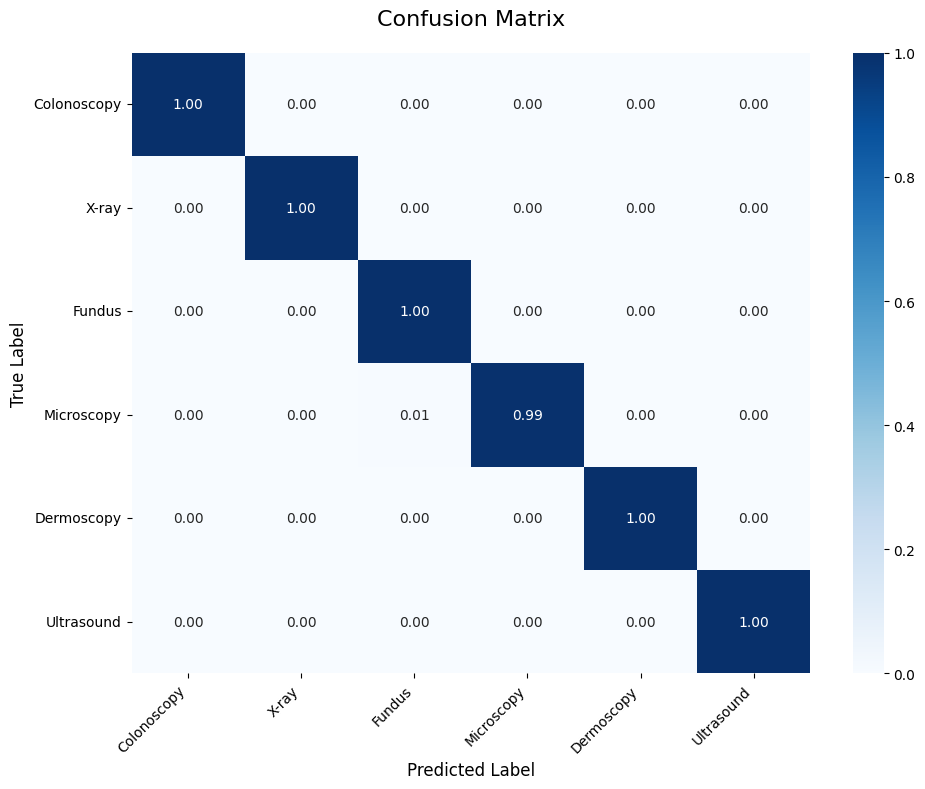


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy     X-ray    Fundus  Microscopy  Dermoscopy  \
Colonoscopy          1.0  0.000000  0.000000    0.000000    0.000000   
X-ray                0.0  1.000000  0.000000    0.000000    0.000000   
Fundus               0.0  0.000000  1.000000    0.000000    0.000000   
Microscopy           0.0  0.000000  0.007463    0.992537    0.000000   
Dermoscopy           0.0  0.001353  0.000000    0.001353    0.997294   
Ultrasound           0.0  0.000000  0.000000    0.000000    0.000000   

             Ultrasound  
Colonoscopy         0.0  
X-ray               0.0  
Fundus              0.0  
Microscopy          0.0  
Dermoscopy          0.0  
Ultrasound          1.0  


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 0.9993
  Recall:    1.0000
  F1-Score:  0.9996
  Support:   1341.0

类别: Fundus
  Precision: 0.8889
  Recall:    1.0000
  F1-Score:  0.9412
 

Epoch [4/100]: 100%|██████████████████████████████| 298/298 [00:28<00:00, 10.62it/s, Loss=0.0000, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00,  9.52it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0204
  准确率: 99.58%
  总样本数: 2377
  正确数: 2367


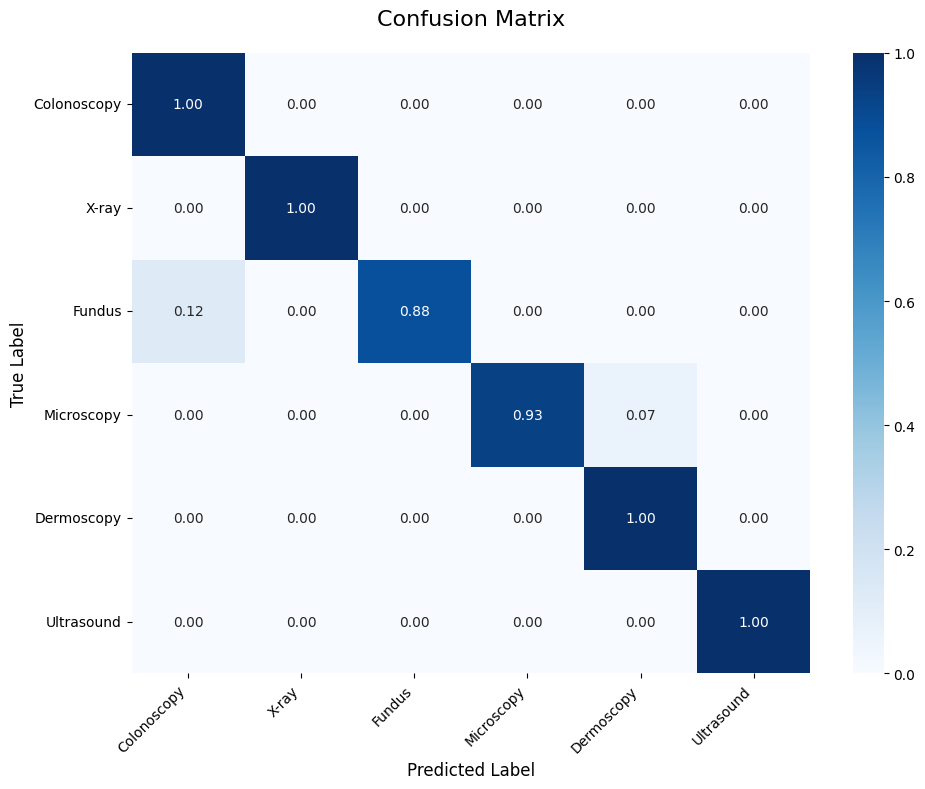


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy        1.000    0.0   0.000    0.000000    0.000000         0.0
X-ray              0.000    1.0   0.000    0.000000    0.000000         0.0
Fundus             0.125    0.0   0.875    0.000000    0.000000         0.0
Microscopy         0.000    0.0   0.000    0.932836    0.067164         0.0
Dermoscopy         0.000    0.0   0.000    0.000000    1.000000         0.0
Ultrasound         0.000    0.0   0.000    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 0.9919
  Recall:    1.0000
  F1-Score:  0.9959
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    0.8750
  F1-Score:  0.9333
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9328
  F1-Score:  0.9653
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9880
  Recall

Epoch [5/100]: 100%|██████████████████████████████| 298/298 [00:29<00:00, 10.18it/s, Loss=0.0011, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.20it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0018
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


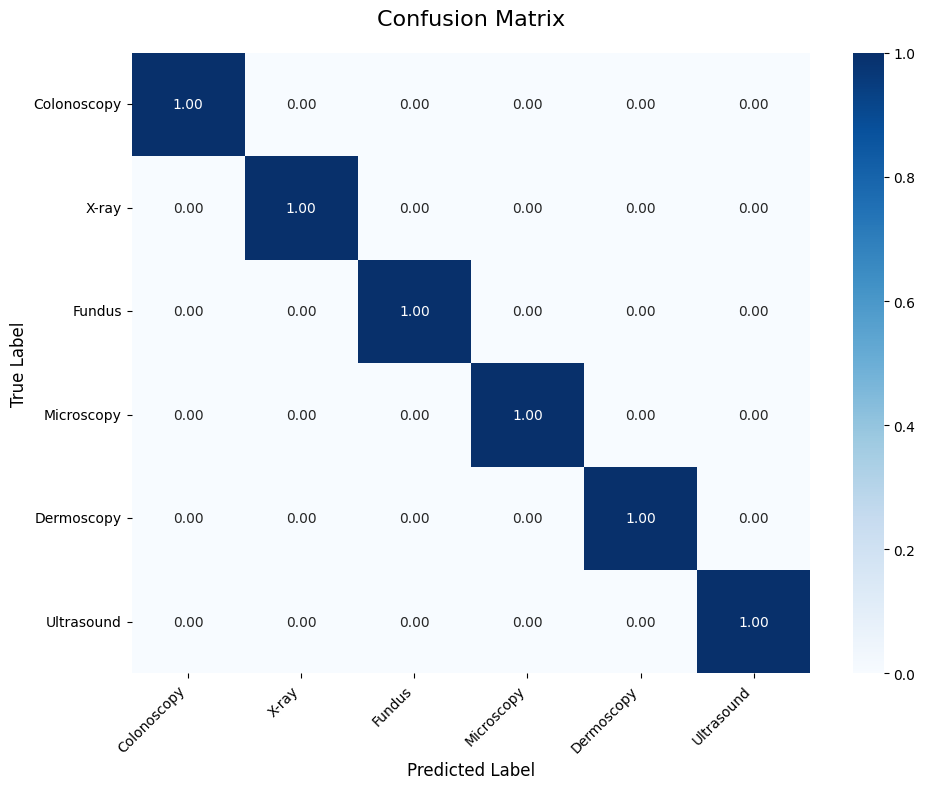


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    1.000000    0.000000         0.0
Dermoscopy           0.0    0.0     0.0    0.002706    0.997294         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 0.9853
  Recall:    1.0000
  F1-Score:  0.9926
  Support:   134.0

类别: Dermoscopy
  Precision: 1.0000
  Recall

Epoch [6/100]: 100%|██████████████████████████████| 298/298 [00:28<00:00, 10.50it/s, Loss=0.0000, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.20it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0140
  准确率: 99.62%
  总样本数: 2377
  正确数: 2368


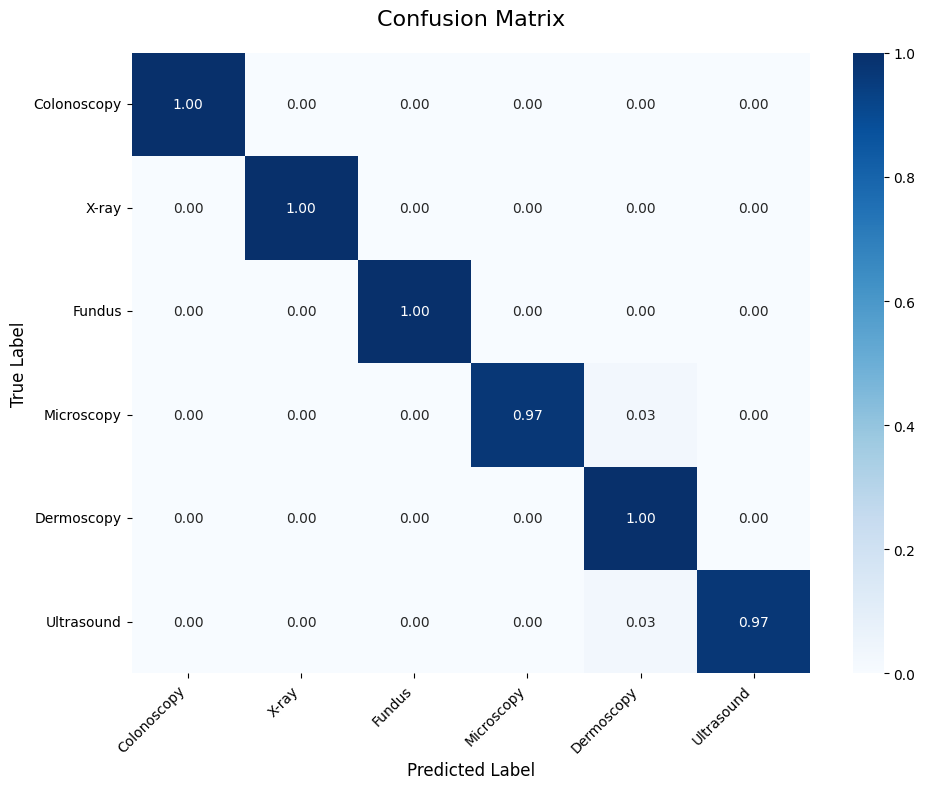


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy     X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0  0.000000     0.0    0.000000    0.000000    0.000000
X-ray                0.0  0.997763     0.0    0.000000    0.002237    0.000000
Fundus               0.0  0.000000     1.0    0.000000    0.000000    0.000000
Microscopy           0.0  0.000000     0.0    0.970149    0.029851    0.000000
Dermoscopy           0.0  0.000000     0.0    0.001353    0.998647    0.000000
Ultrasound           0.0  0.000000     0.0    0.000000    0.030303    0.969697


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    0.9978
  F1-Score:  0.9989
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 0.9924
  Recall:    0.9701
  F1-Score:  0.9811
  Support:   134.0

类别: Dermoscopy
  Preci

Epoch [7/100]: 100%|██████████████████████████████| 298/298 [00:26<00:00, 11.27it/s, Loss=0.0000, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00,  9.74it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0065
  准确率: 99.83%
  总样本数: 2377
  正确数: 2373


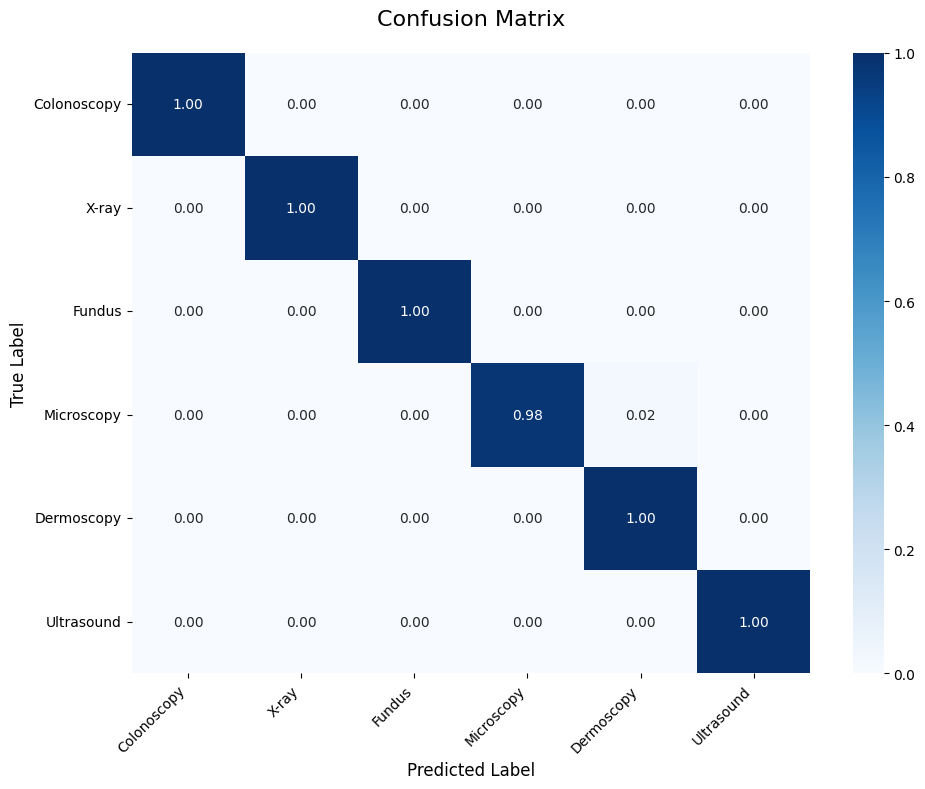


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.977612    0.022388         0.0
Dermoscopy           0.0    0.0     0.0    0.001353    0.998647         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 0.9924
  Recall:    0.9776
  F1-Score:  0.9850
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9960
  Recall

Epoch [8/100]: 100%|██████████████████████████████| 298/298 [00:27<00:00, 10.74it/s, Loss=0.0000, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.06it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0031
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


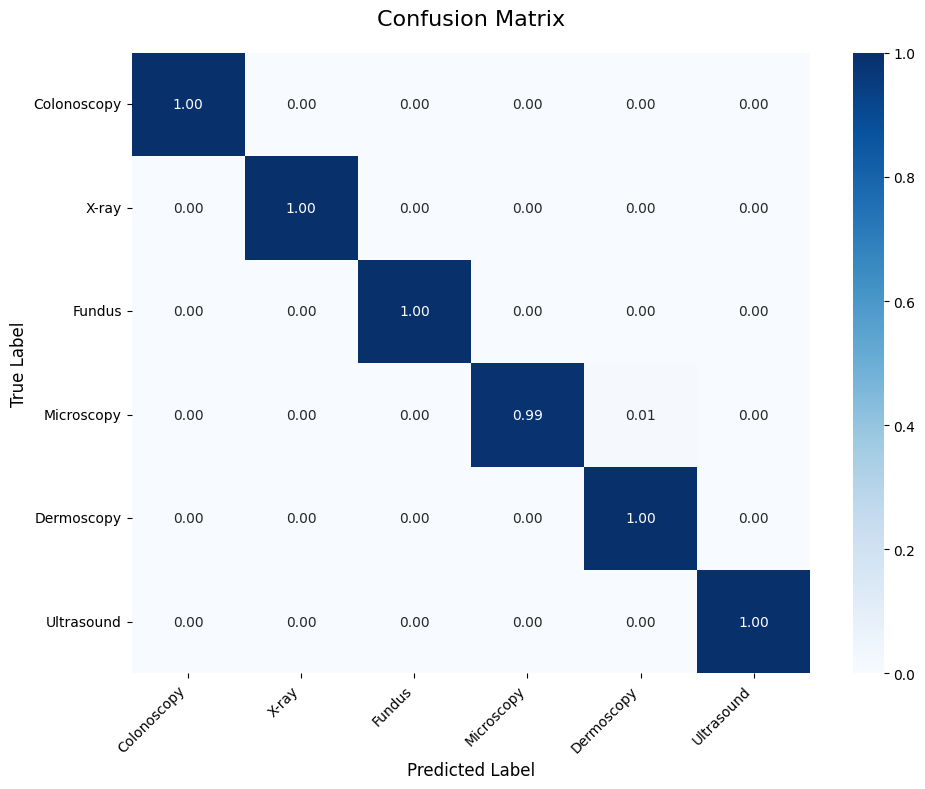


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [9/100]: 100%|██████████████████████████████| 298/298 [00:28<00:00, 10.30it/s, Loss=0.0000, Ac
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.54it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0051
  准确率: 99.83%
  总样本数: 2377
  正确数: 2373


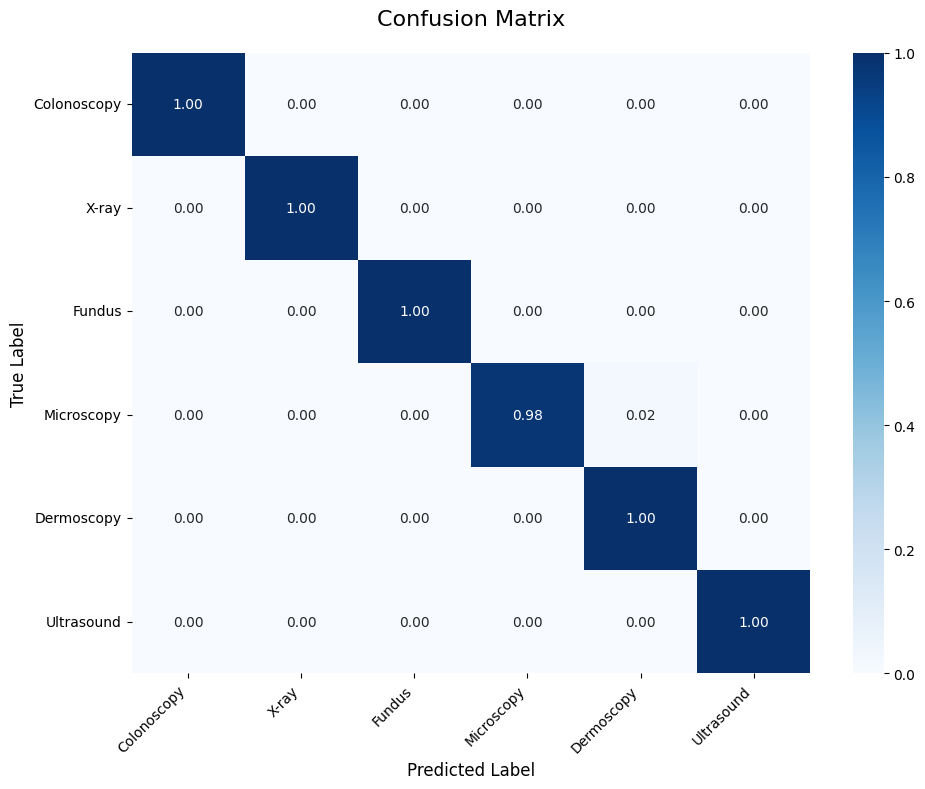


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy     X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0  0.000000     0.0    0.000000    0.000000         0.0
X-ray                0.0  0.999254     0.0    0.000000    0.000746         0.0
Fundus               0.0  0.000000     1.0    0.000000    0.000000         0.0
Microscopy           0.0  0.000000     0.0    0.977612    0.022388         0.0
Dermoscopy           0.0  0.000000     0.0    0.000000    1.000000         0.0
Ultrasound           0.0  0.000000     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    0.9993
  F1-Score:  0.9996
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9776
  F1-Score:  0.9887
  Support:   134.0

类别: Dermoscopy
  Preci

Epoch [10/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.85it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.26it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0028
  准确率: 99.87%
  总样本数: 2377
  正确数: 2374


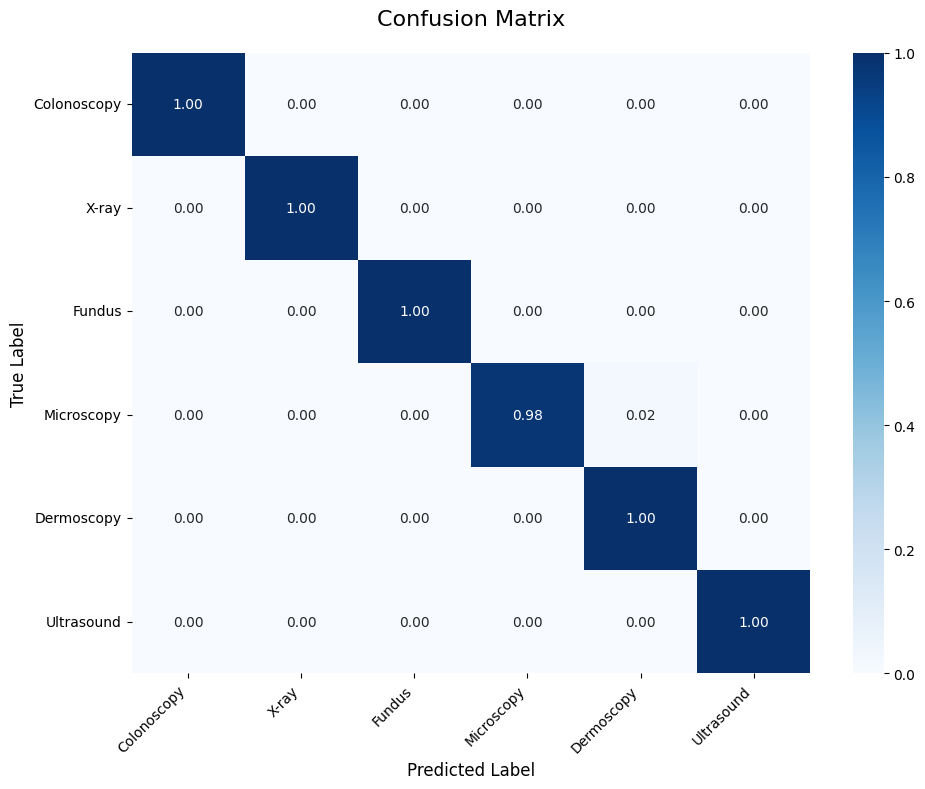


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.977612    0.022388         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9776
  F1-Score:  0.9887
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9960
  Recall

Epoch [11/100]: 100%|██████████████████████████████| 298/298 [00:28<00:00, 10.63it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.06it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0012
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


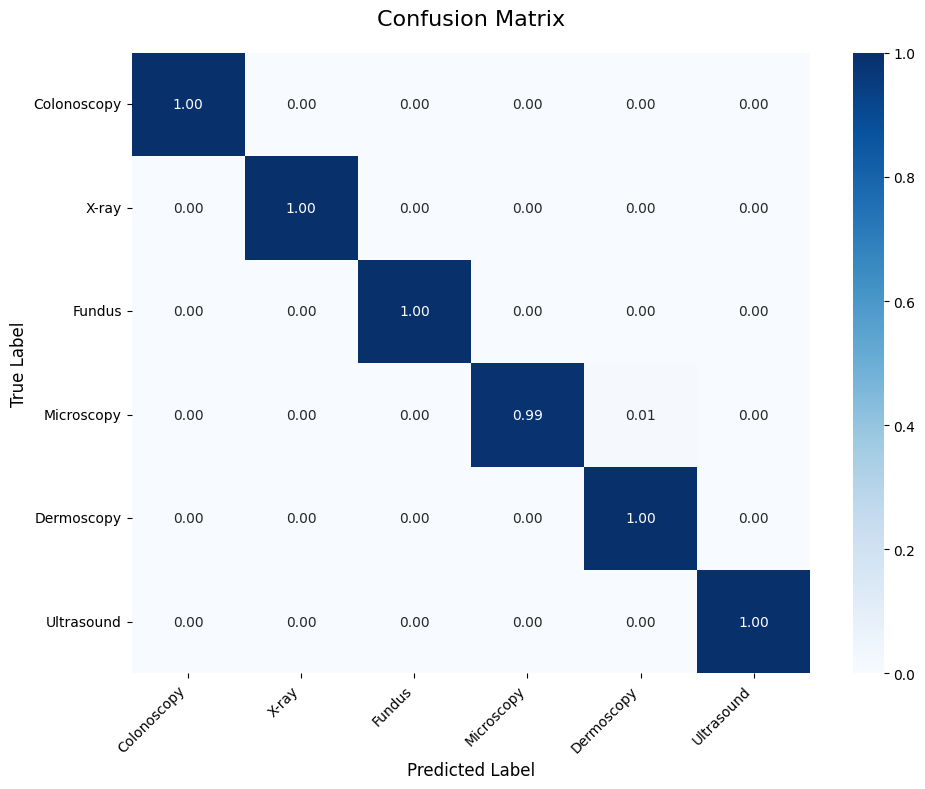


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [12/100]: 100%|██████████████████████████████| 298/298 [00:31<00:00,  9.34it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00,  9.67it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0017
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


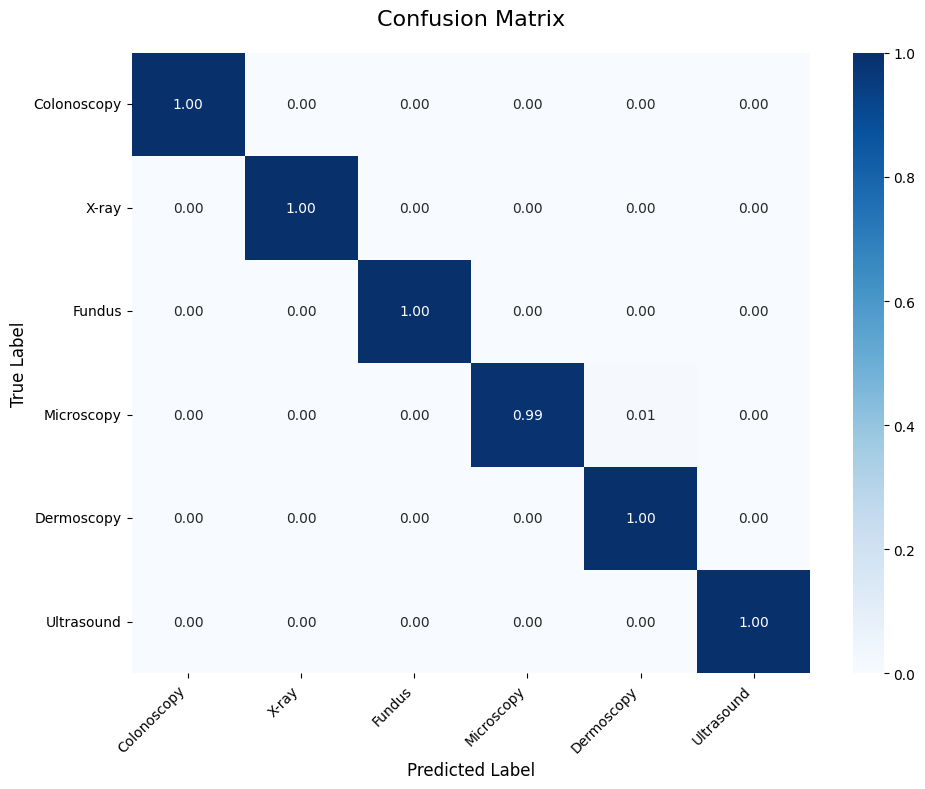


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [13/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.81it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00,  9.97it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0009
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


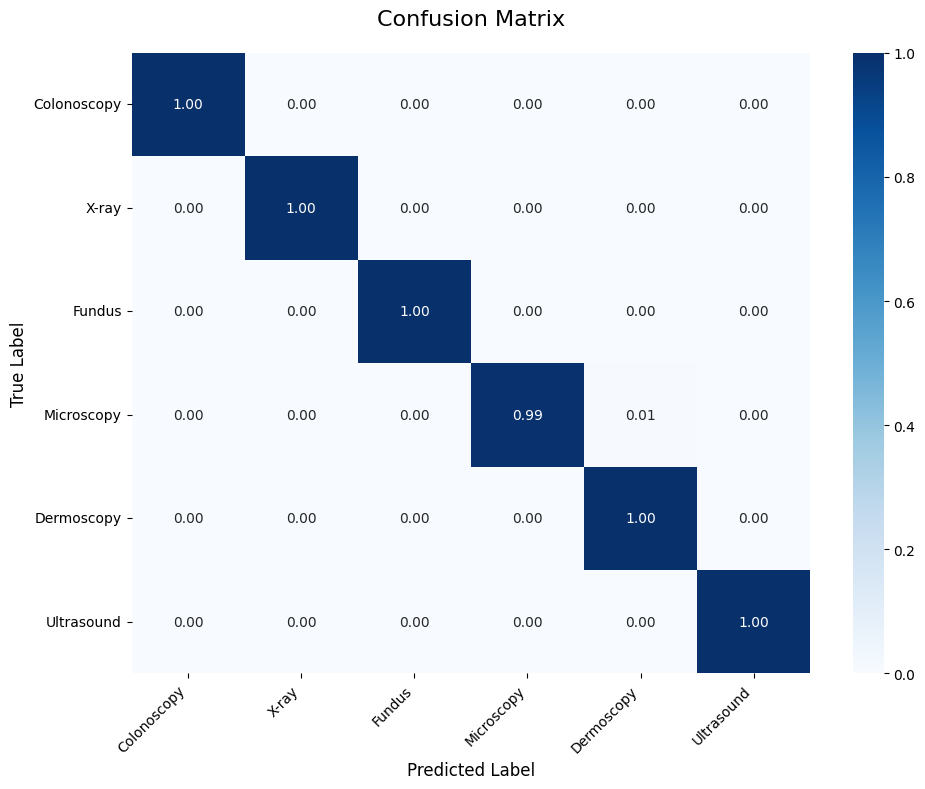


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [14/100]: 100%|██████████████████████████████| 298/298 [00:29<00:00, 10.27it/s, Loss=0.0001, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.94it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0009
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


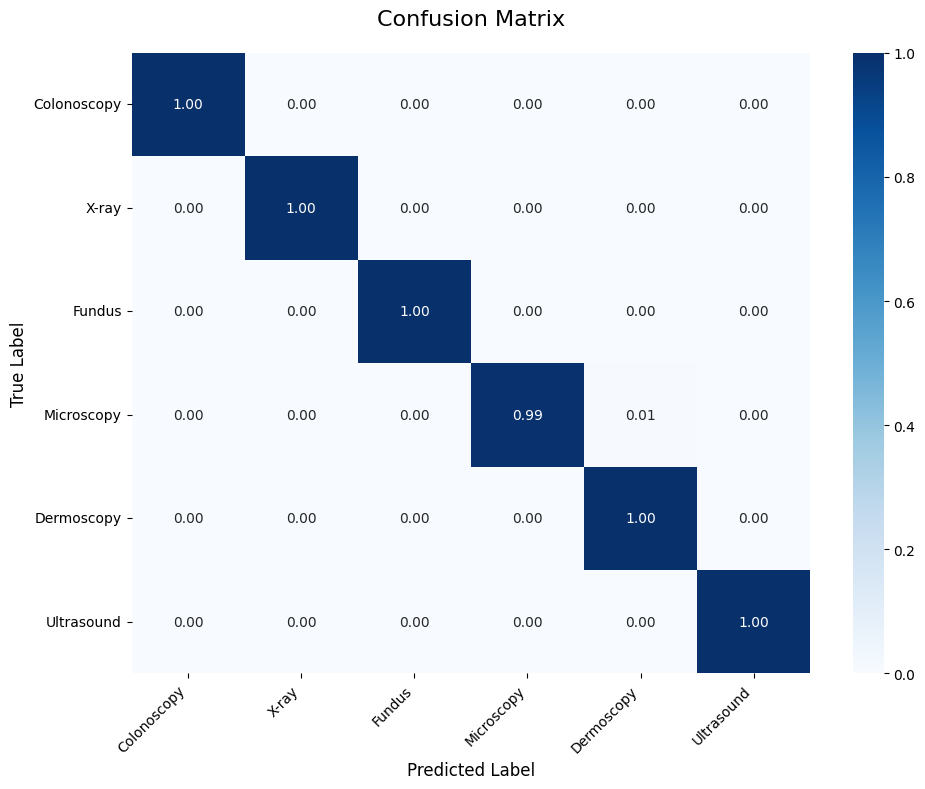


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [15/100]: 100%|██████████████████████████████| 298/298 [00:34<00:00,  8.71it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.11it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0012
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


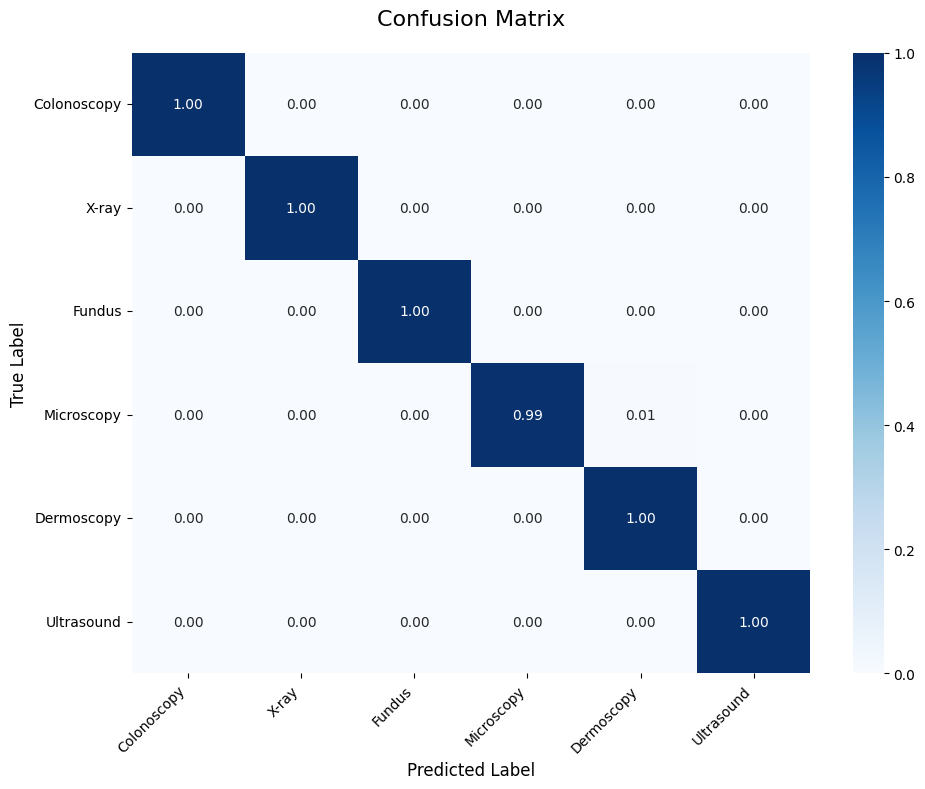


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [16/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.72it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00,  9.91it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0009
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


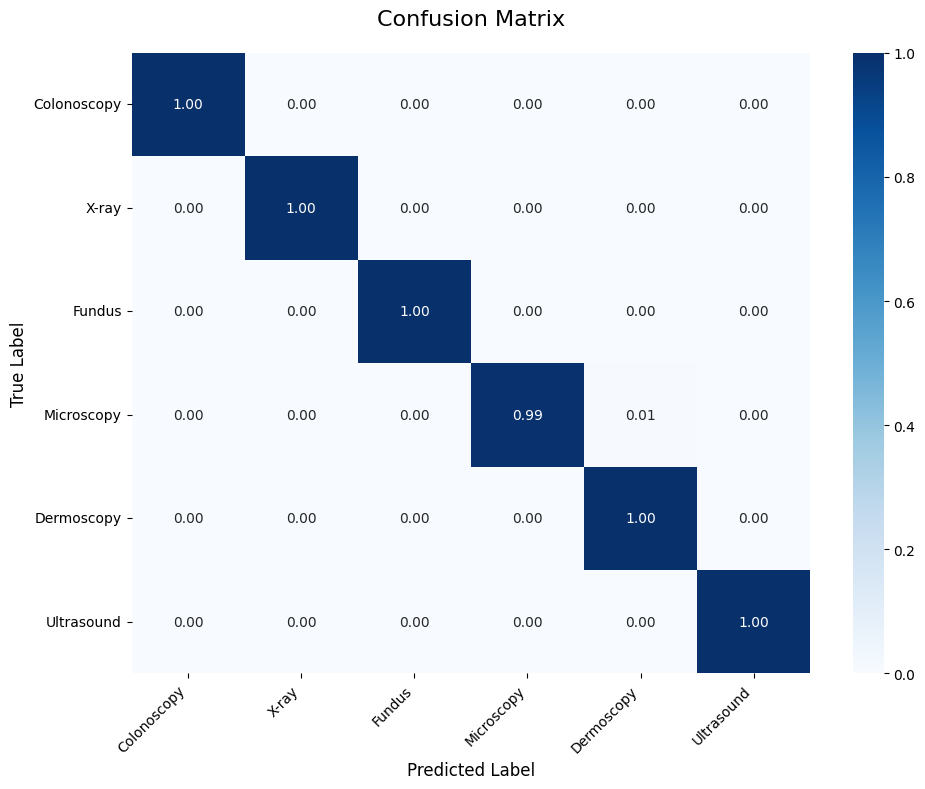


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [17/100]: 100%|██████████████████████████████| 298/298 [00:29<00:00, 10.18it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:09<00:00,  8.27it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0010
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


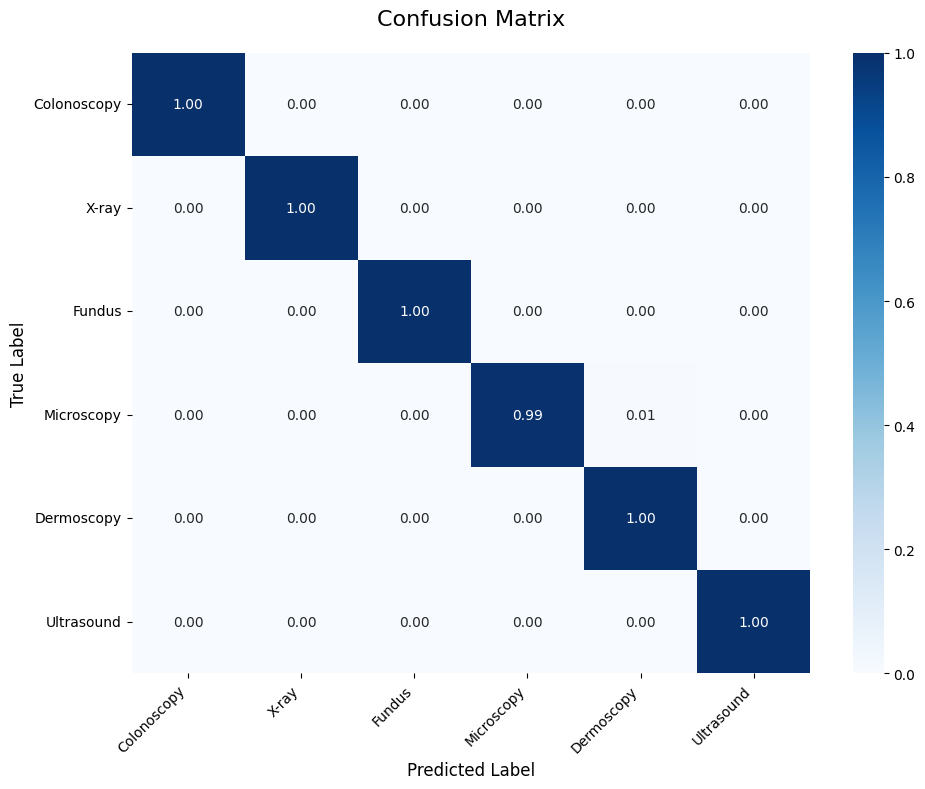


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [18/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.65it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.77it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0014
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


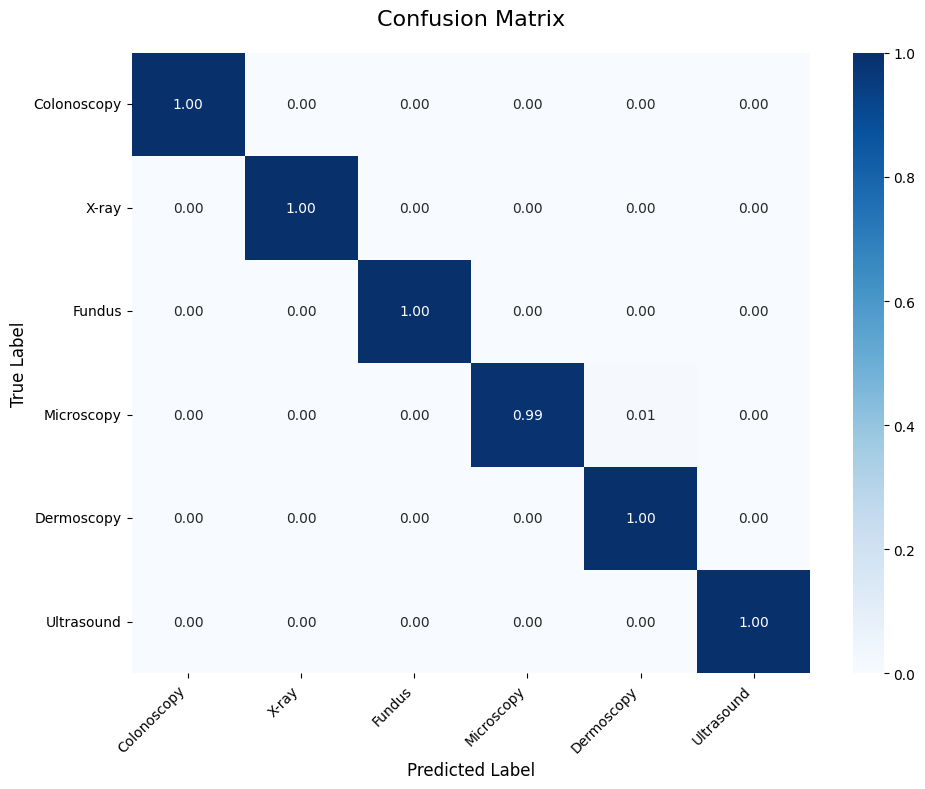


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [19/100]: 100%|██████████████████████████████| 298/298 [00:32<00:00,  9.17it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.67it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0013
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


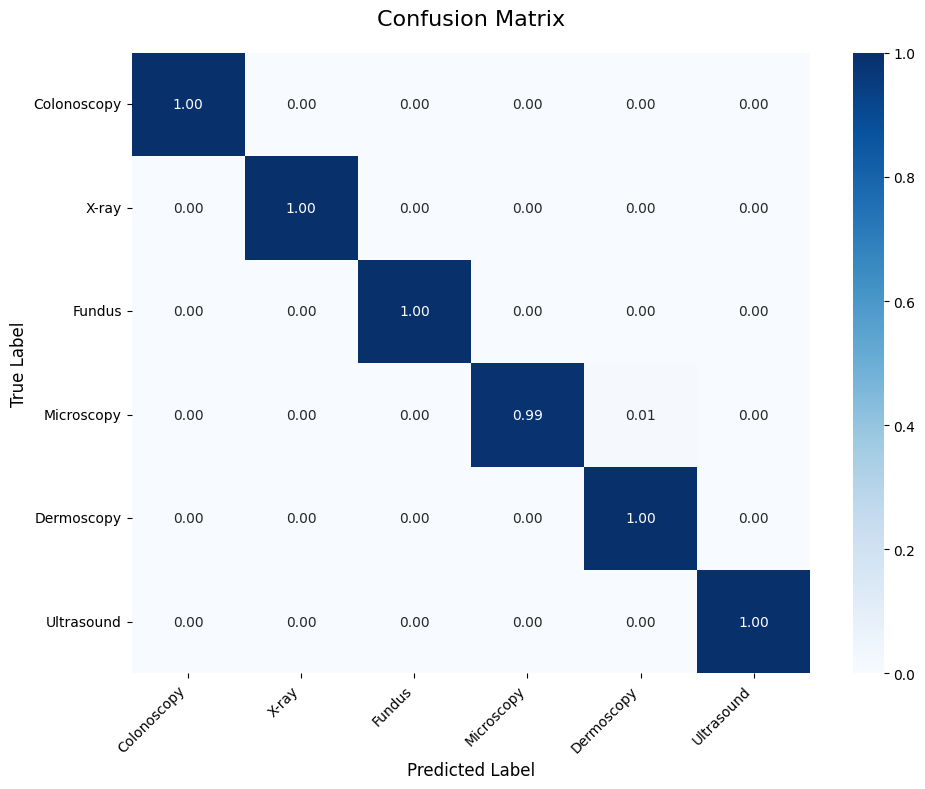


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [20/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.66it/s, Loss=0.0003, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.99it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0010
  准确率: 100.00%
  总样本数: 2377
  正确数: 2377


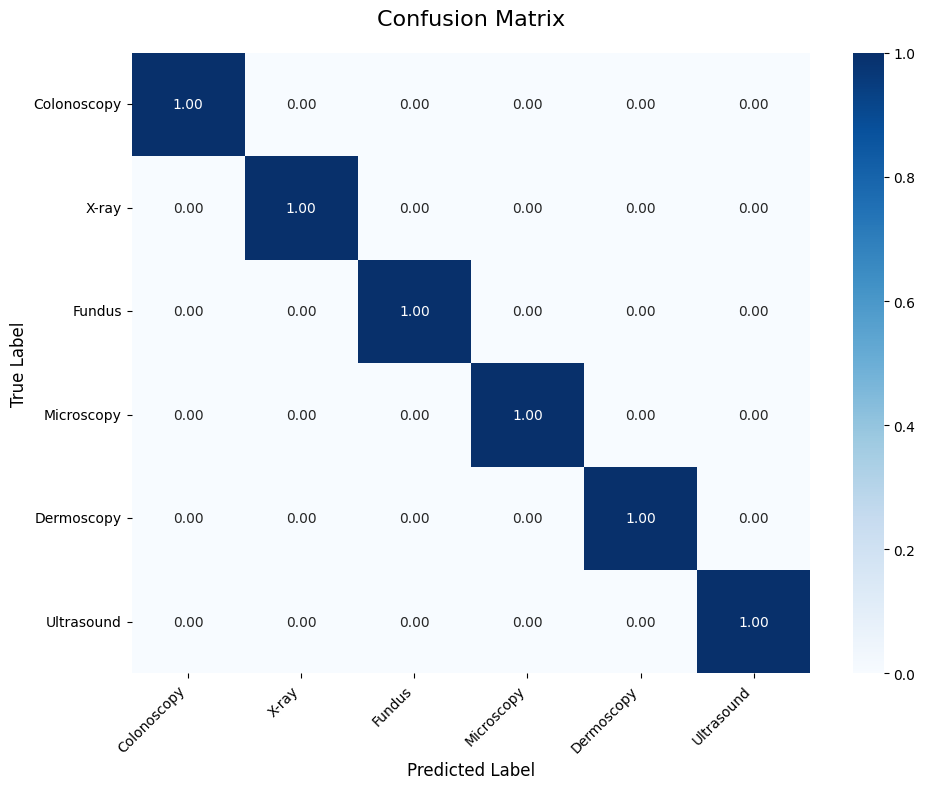


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0         0.0         0.0         0.0
X-ray                0.0    1.0     0.0         0.0         0.0         0.0
Fundus               0.0    0.0     1.0         0.0         0.0         0.0
Microscopy           0.0    0.0     0.0         1.0         0.0         0.0
Dermoscopy           0.0    0.0     0.0         0.0         1.0         0.0
Ultrasound           0.0    0.0     0.0         0.0         0.0         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   134.0

类别: Dermoscopy
  Precision: 1.0000
  Recall

Epoch [21/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.67it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.98it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0009
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


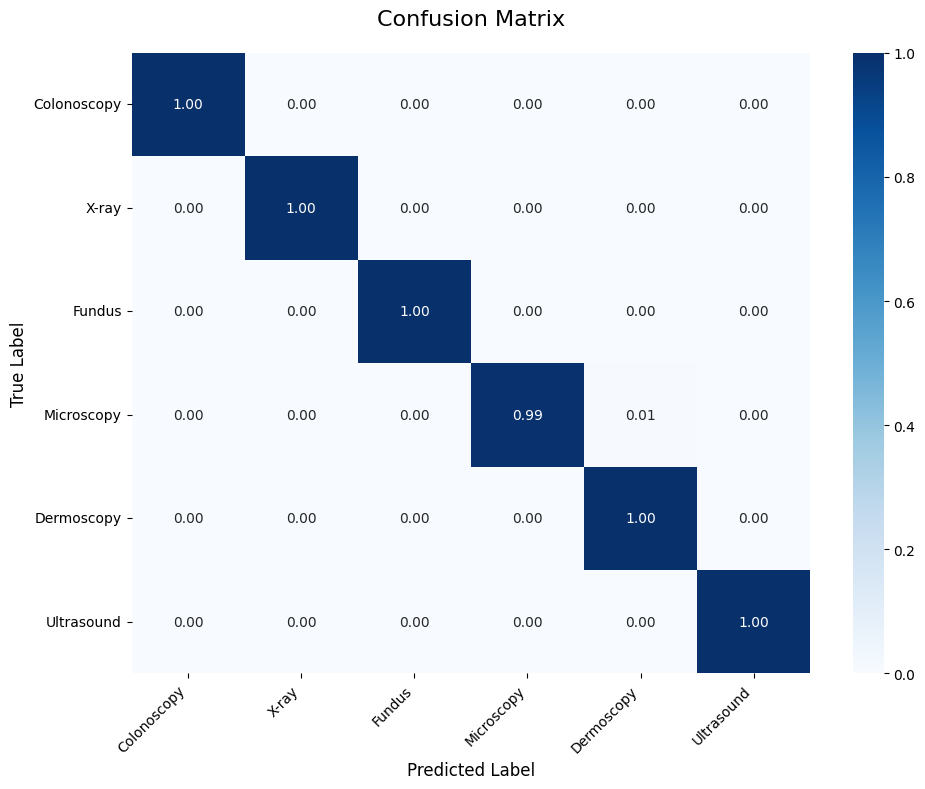


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [22/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.67it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.31it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0008
  准确率: 100.00%
  总样本数: 2377
  正确数: 2377


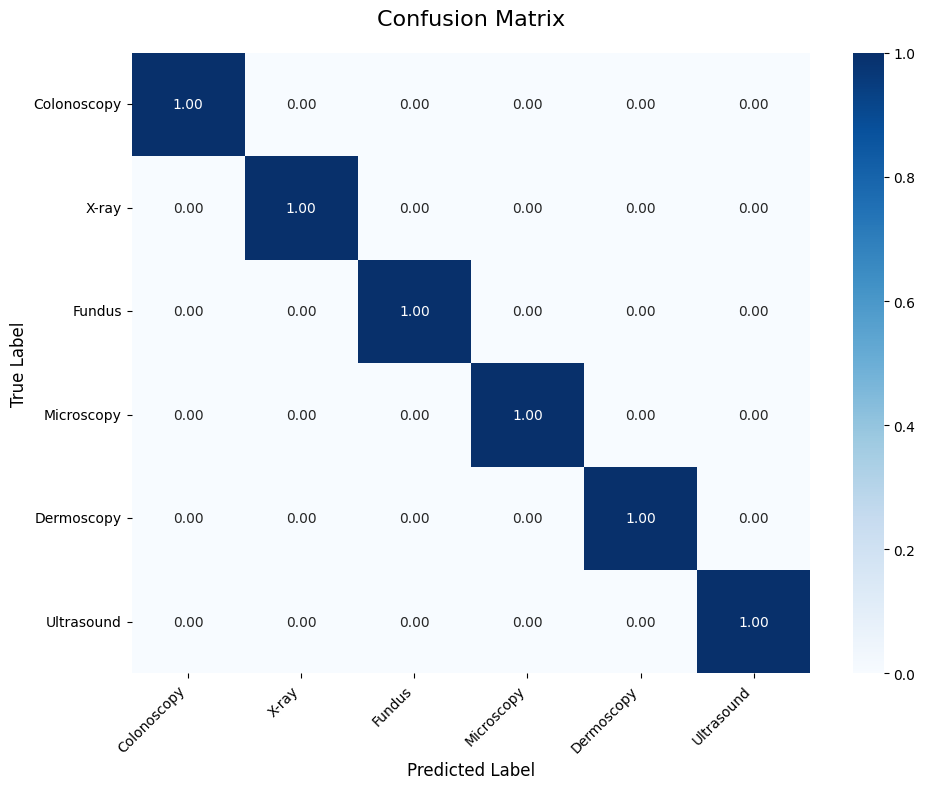


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0         0.0         0.0         0.0
X-ray                0.0    1.0     0.0         0.0         0.0         0.0
Fundus               0.0    0.0     1.0         0.0         0.0         0.0
Microscopy           0.0    0.0     0.0         1.0         0.0         0.0
Dermoscopy           0.0    0.0     0.0         0.0         1.0         0.0
Ultrasound           0.0    0.0     0.0         0.0         0.0         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   134.0

类别: Dermoscopy
  Precision: 1.0000
  Recall

Epoch [23/100]: 100%|██████████████████████████████| 298/298 [00:30<00:00,  9.91it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.75it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0011
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


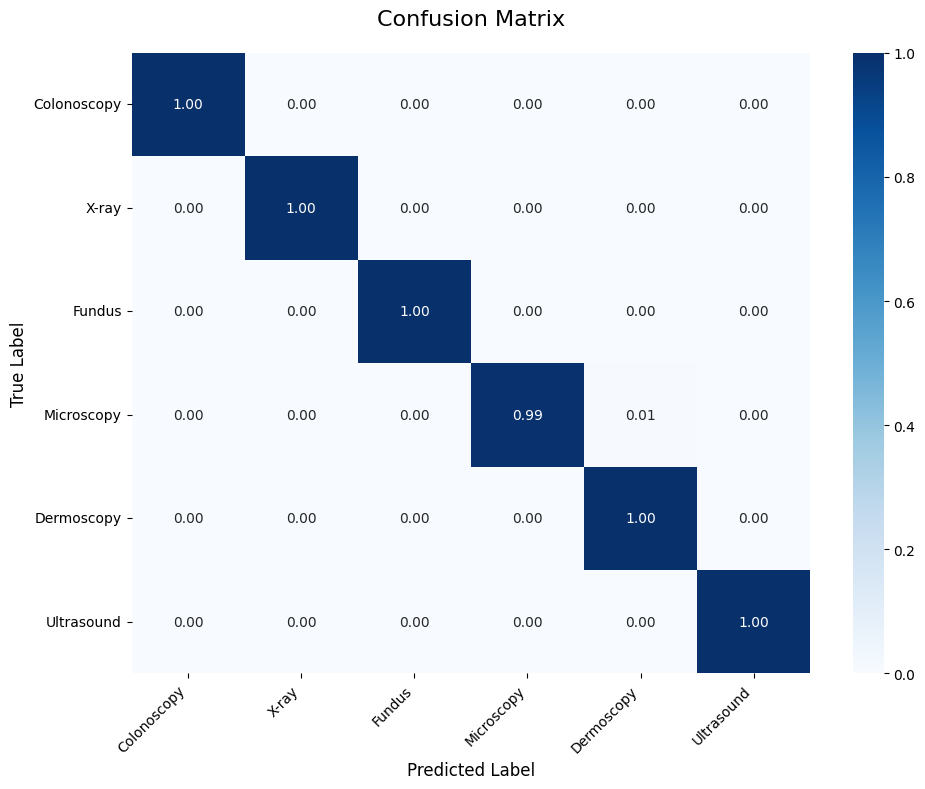


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [24/100]: 100%|██████████████████████████████| 298/298 [00:29<00:00, 10.22it/s, Loss=0.0001, A
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00, 10.18it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0007
  准确率: 100.00%
  总样本数: 2377
  正确数: 2377


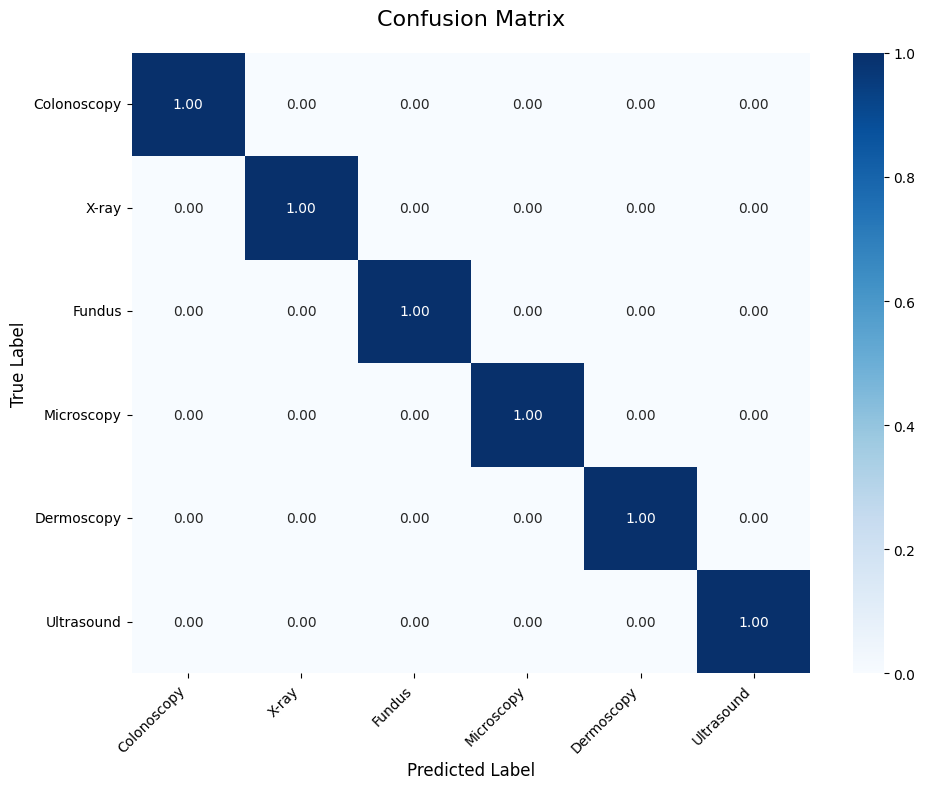


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0         0.0         0.0         0.0
X-ray                0.0    1.0     0.0         0.0         0.0         0.0
Fundus               0.0    0.0     1.0         0.0         0.0         0.0
Microscopy           0.0    0.0     0.0         1.0         0.0         0.0
Dermoscopy           0.0    0.0     0.0         0.0         1.0         0.0
Ultrasound           0.0    0.0     0.0         0.0         0.0         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   134.0

类别: Dermoscopy
  Precision: 1.0000
  Recall

Epoch [25/100]: 100%|██████████████████████████████| 298/298 [00:33<00:00,  8.97it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.25it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0010
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


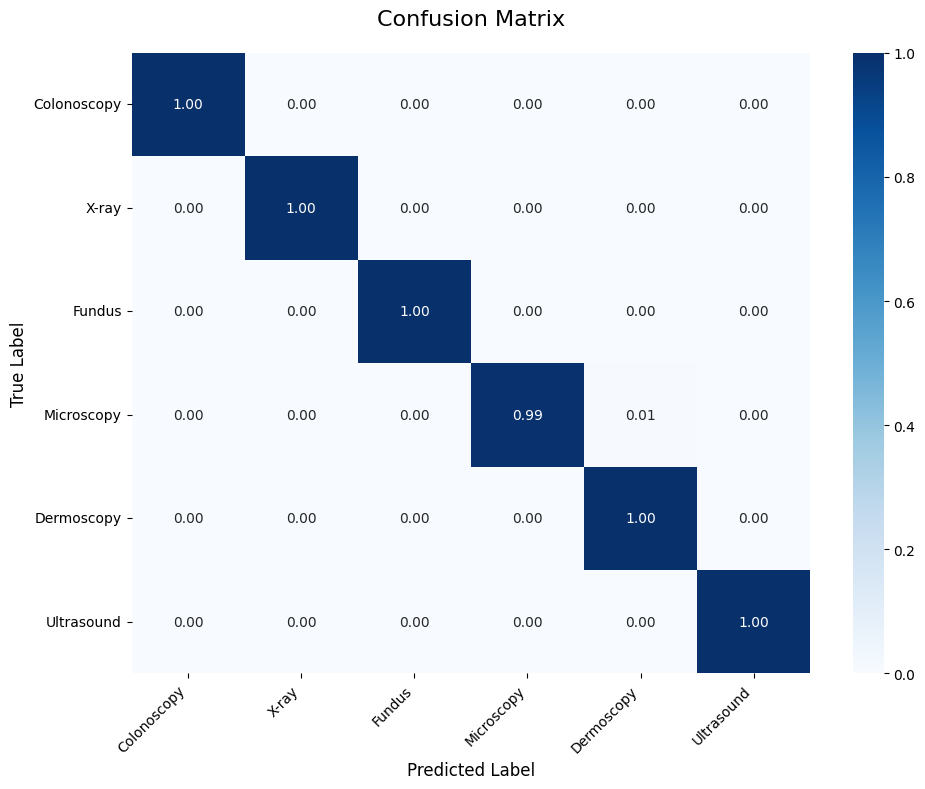


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [26/100]: 100%|██████████████████████████████| 298/298 [00:31<00:00,  9.45it/s, Loss=0.0008, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.03it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0013
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


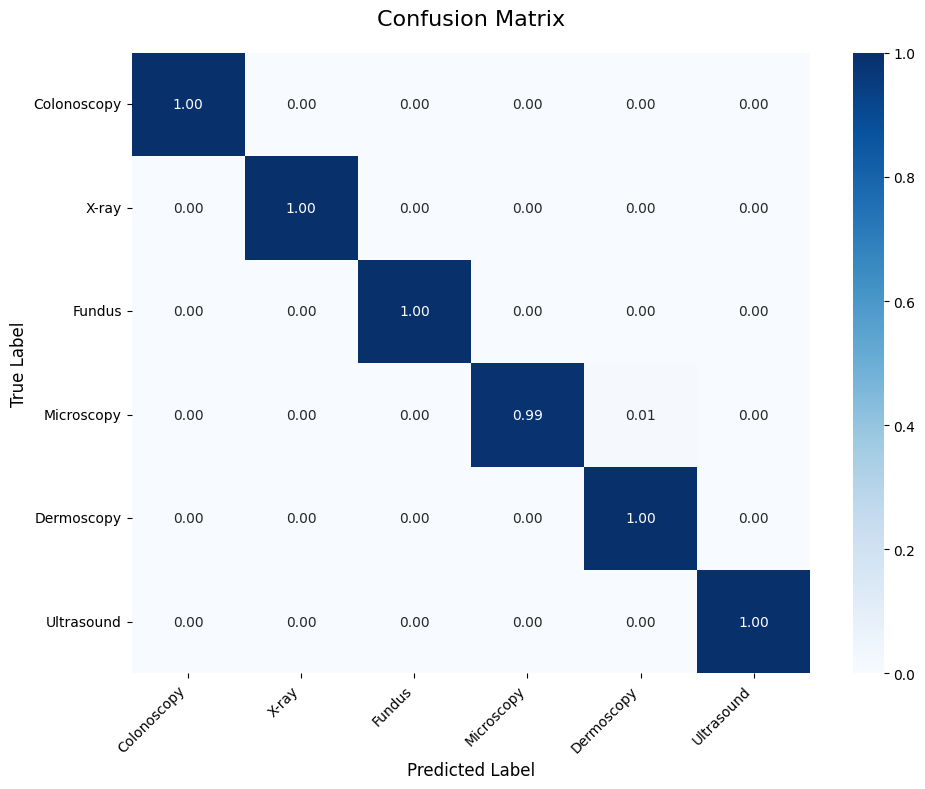


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [27/100]: 100%|██████████████████████████████| 298/298 [00:32<00:00,  9.16it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.15it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0008
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


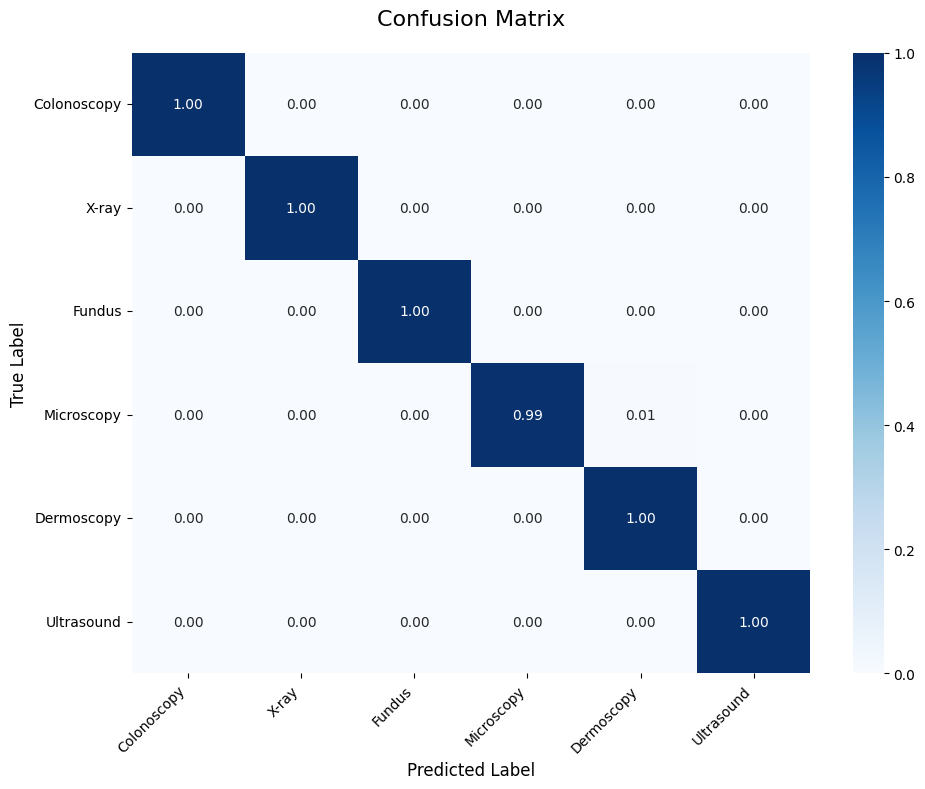


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [28/100]: 100%|██████████████████████████████| 298/298 [00:33<00:00,  9.03it/s, Loss=17.1084, 
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  8.70it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0019
  准确率: 99.92%
  总样本数: 2377
  正确数: 2375


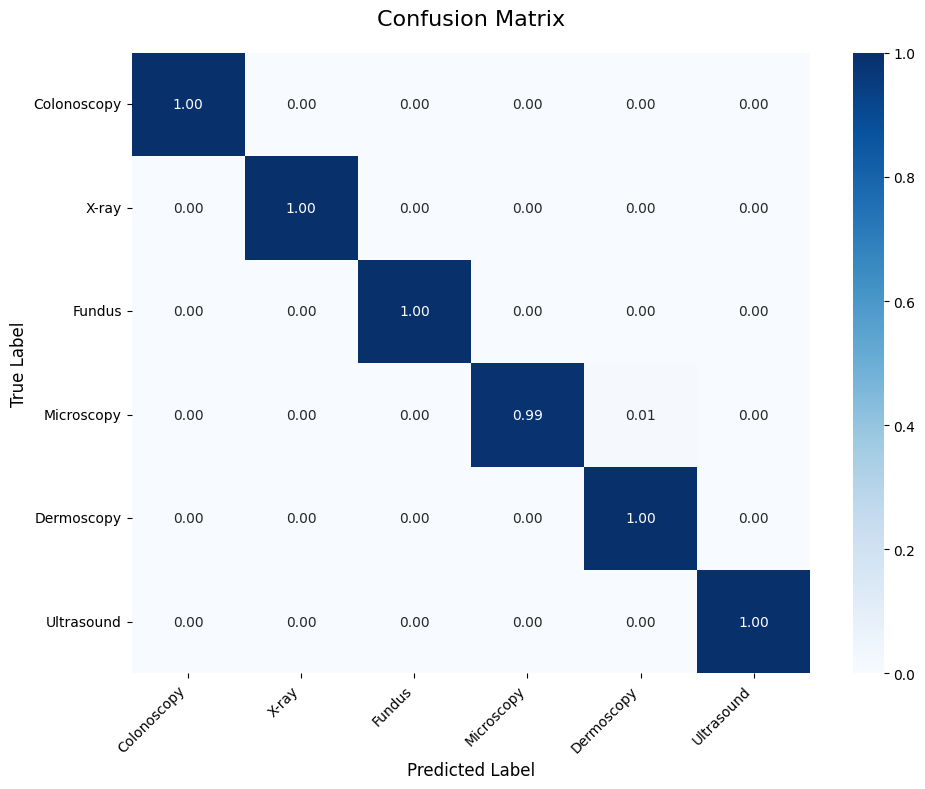


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.985075    0.014925         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9851
  F1-Score:  0.9925
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9973
  Recall

Epoch [29/100]: 100%|██████████████████████████████| 298/298 [00:33<00:00,  8.79it/s, Loss=0.0002, A
Validating: 100%|██████████████████████████████| 75/75 [00:08<00:00,  9.36it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0012
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


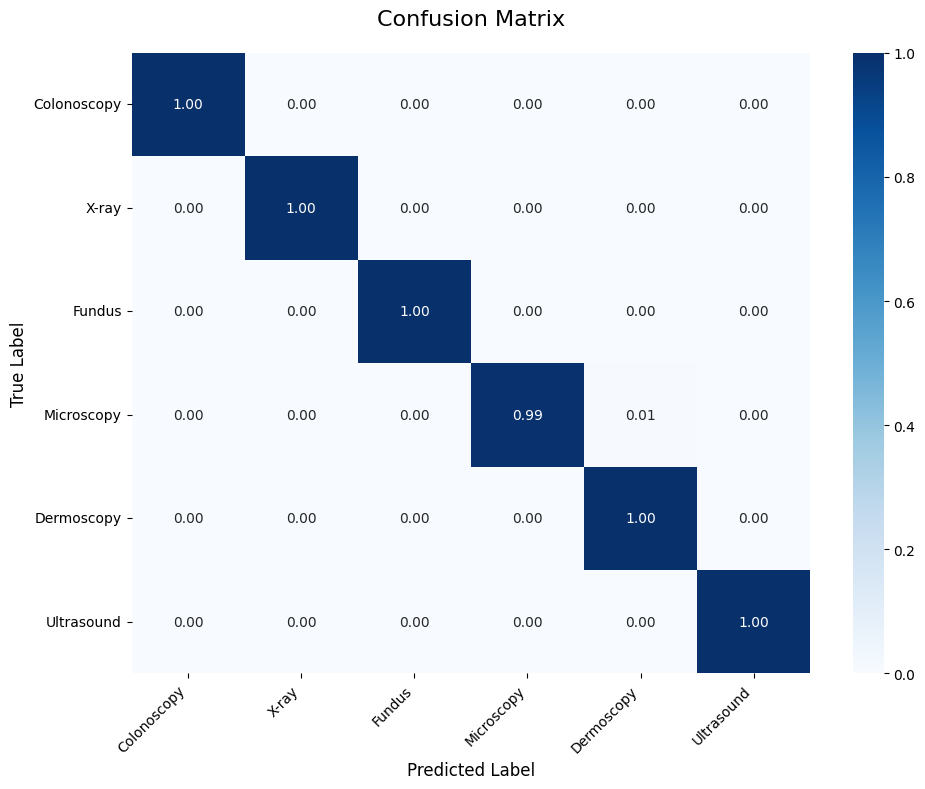


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

Epoch [30/100]: 100%|██████████████████████████████| 298/298 [00:33<00:00,  8.97it/s, Loss=0.0000, A
Validating: 100%|██████████████████████████████| 75/75 [00:07<00:00,  9.54it/s, Val Loss=0.0000, Val



验证结果:
  损失: 0.0011
  准确率: 99.96%
  总样本数: 2377
  正确数: 2376


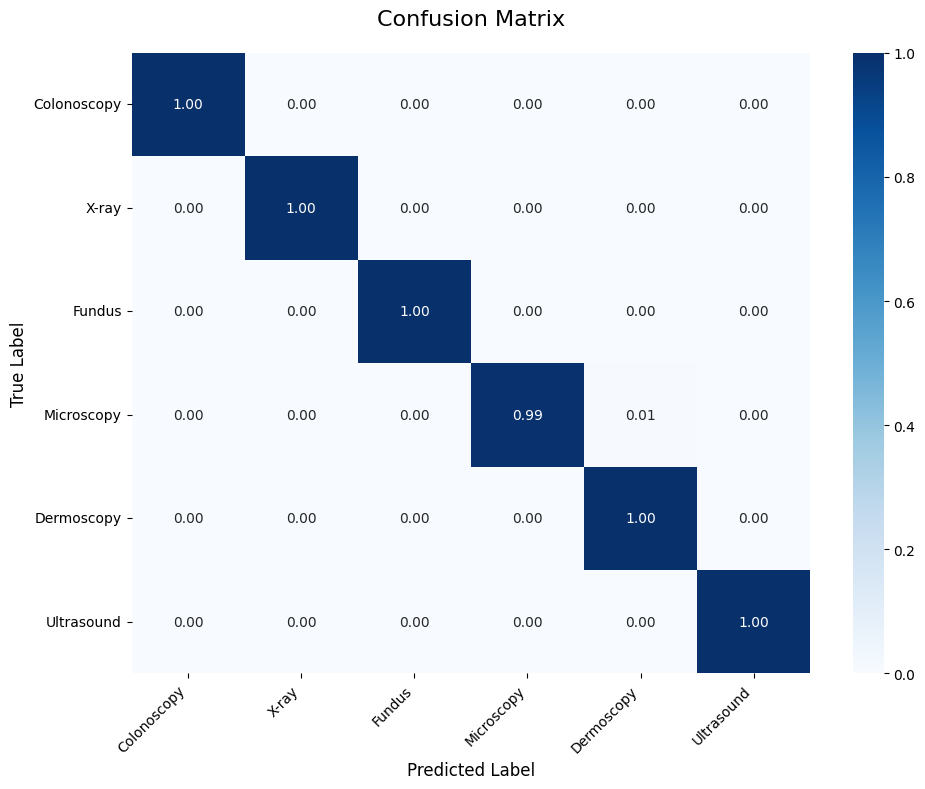


混淆矩阵:
(归一化值，显示每个真实类别的预测比例)

混淆矩阵 DataFrame:
             Colonoscopy  X-ray  Fundus  Microscopy  Dermoscopy  Ultrasound
Colonoscopy          1.0    0.0     0.0    0.000000    0.000000         0.0
X-ray                0.0    1.0     0.0    0.000000    0.000000         0.0
Fundus               0.0    0.0     1.0    0.000000    0.000000         0.0
Microscopy           0.0    0.0     0.0    0.992537    0.007463         0.0
Dermoscopy           0.0    0.0     0.0    0.000000    1.000000         0.0
Ultrasound           0.0    0.0     0.0    0.000000    0.000000         1.0


分类报告:

类别: Colonoscopy
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   122.0

类别: X-ray
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   1341.0

类别: Fundus
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   8.0

类别: Microscopy
  Precision: 1.0000
  Recall:    0.9925
  F1-Score:  0.9963
  Support:   134.0

类别: Dermoscopy
  Precision: 0.9986
  Recall

In [27]:
def main():

    # 设置设备
    device_ids = list(range(torch.cuda.device_count()))
    device = torch.device(f"cuda:{device_ids[0]}" if device_ids else "cpu")
    print(f"可用 GPU: {device_ids}")
    print(f"main GPU is device {device_ids[0]}")
    print("=" * 80)
    
    # 创建保存目录
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"MI_experiments/exp_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    print(f"📁 实验保存目录: {save_dir}")
    
    # 初始化模型
    model = Modality_Inspector(num_classes=6).to(device)
    
    # 打印模型信息
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 模型参数统计:")
    print(f"   总参数量: {total_params:,}")
    print(f"   可训练参数量: {trainable_params:,}")
    print("-" * 80)
    
    # 定义损失函数和优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # 学习率调度器
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,           # 优化器
        mode='min',          # 监控指标的模式：'min' 或 'max'
        factor=0.1,          # 学习率衰减因子
        patience=4,         # 耐心期（多少个epoch没有改善）
        threshold=1e-4,      # 改善的阈值
        threshold_mode='rel',# 阈值模式：'rel' 相对或 'abs' 绝对
        cooldown=0,          # 冷却期（调整学习率后等待多少个epoch）
        min_lr=0,            # 最小学习率
        eps=1e-8,            # 数值稳定性
    )
    

    print(f"📦 数据集信息:")
    print(f"   训练集大小: {len(train_dataset)}")
    print(f"   验证集大小: {len(val_dataset)}")
    print(f"   批大小: 32")
    print("-" * 80)
    
    # 训练参数
    num_epochs = 100
    best_val_acc = 0.0
    early_stop_patience = 10
    no_improve_count = 0
    
    # 训练历史记录
    history = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rate': [],
        'time_per_epoch': []
    }
    
    print("🚀 开始训练...")
    print("=" * 80)
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # 训练一个epoch
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, epoch, num_epochs
        )
        
        # 验证
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # 计算时间
        epoch_time = time.time() - epoch_start_time
        
        # 更新学习率
        scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]['lr']
        
        # 记录历史
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(current_lr)
        history['time_per_epoch'].append(epoch_time)
        
        # 打印 epoch 总结
        print(f"\n📈 Epoch {epoch+1:03d}/{num_epochs} 总结:")
        print(f"   ├── 训练损失: {train_loss:.4f}  |  训练准确率: {train_acc:.2f}%")
        print(f"   ├── 验证损失: {val_loss:.4f}  |  验证准确率: {val_acc:.2f}%")
        print(f"   ├── 学习率: {current_lr:.6f}")
        print(f"   └── 耗时: {epoch_time:.2f}秒")
        print("-" * 80)
        
        # 保存最佳模型
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            no_improve_count = 0
            print(f"🏆 新的最佳验证准确率: {val_acc:.2f}%")
        else:
            no_improve_count += 1
            print(f"⏳ 最佳准确率未提升: {best_val_acc:.2f}% (耐心计数: {no_improve_count}/{early_stop_patience})")
        
        # 保存检查点
        metrics = {
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        }

        ## 初次检查
        if epoch == 0:
            save_checkpoint(model, optimizer, epoch, metrics, save_dir, is_best)
            save_training_history(history, save_dir)
        
        # 每5个epoch保存一次检查点
        if (epoch + 1) % 5 == 0 or is_best or epoch == num_epochs - 1:
            save_checkpoint(model, optimizer, epoch, metrics, save_dir, is_best)
        
        # 保存训练历史        
        if (epoch + 1) % 10 == 0 or epoch == num_epochs - 1:
            save_training_history(history, save_dir)
        
        # 早停检查
        if no_improve_count >= early_stop_patience:
            print(f"⏹️  早停触发: 验证准确率连续{early_stop_patience}轮未提升")
            break
    
    print("=" * 80)
    print("🎉 训练完成!")
    
    # 最终保存
    print("\n💾 保存最终结果...")
    
    # 保存最终模型
    final_model_path = os.path.join(save_dir, 'final_mobile_mi_model.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes': 6,
        'config': {
            'input_shape': (256, 64, 64),
            'num_epochs': num_epochs,
            'best_val_acc': best_val_acc
        }
    }, final_model_path)
    print(f"✅ 最终模型已保存到: {final_model_path}")
    
    # 保存训练历史
    csv_path = save_training_history(history, save_dir)
    
    # 绘制训练曲线
    plot_training_history(history, save_dir)
    
    # 打印最终统计
    print("\n📊 训练结果统计:")
    print(f"   最佳验证准确率: {best_val_acc:.2f}%")
    print(f"   最终训练准确率: {history['train_acc'][-1]:.2f}%")
    print(f"   最终验证准确率: {history['val_acc'][-1]:.2f}%")
    print(f"   总训练轮数: {len(history['epoch'])}")
    print(f"   总训练时间: {sum(history['time_per_epoch']):.2f}秒")
    
    # 显示训练历史表格
    print("\n📋 训练历史摘要:")
    df = pd.DataFrame(history)
    print(df.tail().to_string(index=False))  # 显示最后5个epoch
    
    return model, history


# 运行训练
trained_model, training_history = main()

In [ ]:
def predict(model, input_data, device='cuda'):
    """使用训练好的模型进行预测"""
    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
        if len(input_tensor.shape) == 3:  # 如果是单个样本
            input_tensor = input_tensor.unsqueeze(0)
        
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
    return predicted.cpu().numpy(), probabilities.cpu().numpy()


# 加载已保存的模型
def load_trained_model(checkpoint_path, device='cuda'):
    """加载训练好的模型"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = Modality_Inspector(num_classes=6).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"✅ 模型加载成功: {checkpoint_path}")
    if 'best_val_acc' in checkpoint:
        print(f"   模型准确率: {checkpoint['best_val_acc']:.2f}%")
    
    return model



# 示例: 使用训练好的模型进行预测
print("\n🧪 模型测试示例:")
test_sample = np.random.randn(1, 256, 64, 64).astype(np.float32)

predictions, probabilities = predict(trained_model, test_sample)

print(f"预测类别: {predictions[0]}")
print(f"类别概率: {probabilities[0]}")
print(f"最可能的类别: {np.argmax(probabilities[0])} (概率: {np.max(probabilities[0]):.4f})")

In [18]:
trained_model.eval()
dataloader = val_loader

device_ids = list(range(torch.cuda.device_count()))
device = torch.device(f"cuda:{device_ids[0]}" if device_ids else "cpu")
print(f"可用 GPU: {device_ids}")
print(f"main GPU is device {device_ids[0]}")

all_predictions, all_targets = [] , []

with torch.no_grad():
    pbar = tqdm(dataloader, 
                desc='Validating',
                ncols=100,
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')
    
    for data, target in pbar:
        data, target = data.to(device), target.to(device)
        outputs = trained_model(data)

        # 获取预测结果
        _, predicted = torch.max(outputs.data, 1)
        
        # 保存预测和真实标签
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

NameError: name 'trained_model' is not defined

In [141]:
for idx in range(len(all_predictions)):
    if all_predictions[idx] != all_targets[idx]:
        print(idx, all_targets[idx], idx_name[all_targets[idx]], " -> ", idx_name[all_predictions[idx]])

816 4 Dermoscopy  ->  Microscopy
2306 3 Microscopy  ->  Dermoscopy


In [143]:
X_val[816]

'ISIC_2018_set_file_ISIC_0010361.pt'

In [144]:
X_val[2306]

'DSB_2018_set_file_487.pt'